In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jsphyg/weather-dataset-rattle-package/weatherAUS.csv


# 🌧️ Rain Prediction in Australia — Random Forest Classifier

## Problem Statement
Predict whether it will **rain tomorrow** in Australia based on today's weather observations.
This is a **binary classification** problem with real-world meteorological data.

## Dataset
- **Source:** [Kaggle — Rain in Australia](https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package)
- **Rows:** ~145,000 weather observations
- **Target:** `RainTomorrow` → Yes / No

## Why Random Forest?
Logistic Regression draws a **linear boundary** between classes.  
Random Forest builds **100s of decision trees** on random subsets of data and features,  
then takes a majority vote — making it powerful for **non-linear, complex patterns**.

## Notebook Roadmap
1. Imports & Data Loading  
2. Exploratory Data Analysis (EDA)  
3. Preprocessing (Missing Values, Encoding, Scaling)  
4. Random Forest — Baseline Model  
5. Evaluation (Confusion Matrix, ROC-AUC, Feature Importance)  
6. Hyperparameter Tuning  
7. Final Results & Key Learnings

In [4]:
# ============================================================
# RAIN PREDICTION IN AUSTRALIA — RANDOM FOREST CLASSIFIER
# Dataset: Weather Dataset (Rattle Package) — Kaggle
# Goal: Predict RainTomorrow (Yes/No)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)

# --- Load Data ---
df = pd.read_csv('/kaggle/input/datasets/jsphyg/weather-dataset-rattle-package/weatherAUS.csv')

print("📐 Shape:", df.shape)
print("\n🎯 Target Distribution:")
print(df['RainTomorrow'].value_counts())
print(df['RainTomorrow'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

display(df.head())

📐 Shape: (145460, 23)

🎯 Target Distribution:
RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64
RainTomorrow
No     77.58%
Yes    22.42%
Name: proportion, dtype: object


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


## 2. Exploratory Data Analysis

Before building any model, we need to **understand the data visually**:
- How imbalanced is our target?
- Which features have the most missing values?
- How do key weather features differ on rainy vs non-rainy days?

>  EDA is not optional — it directly informs every preprocessing decision we make.

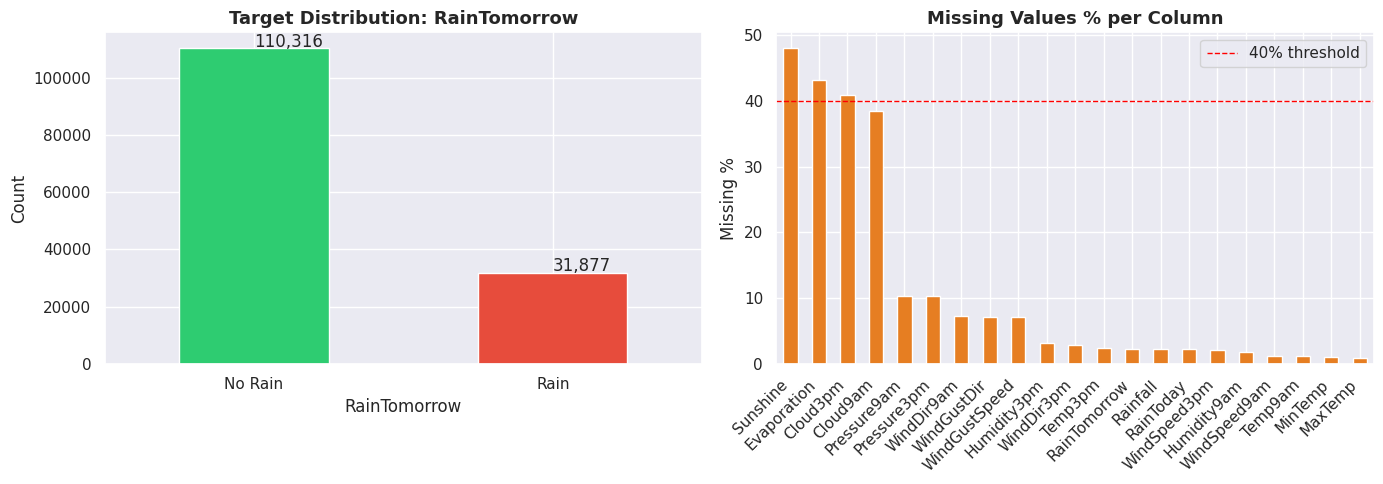

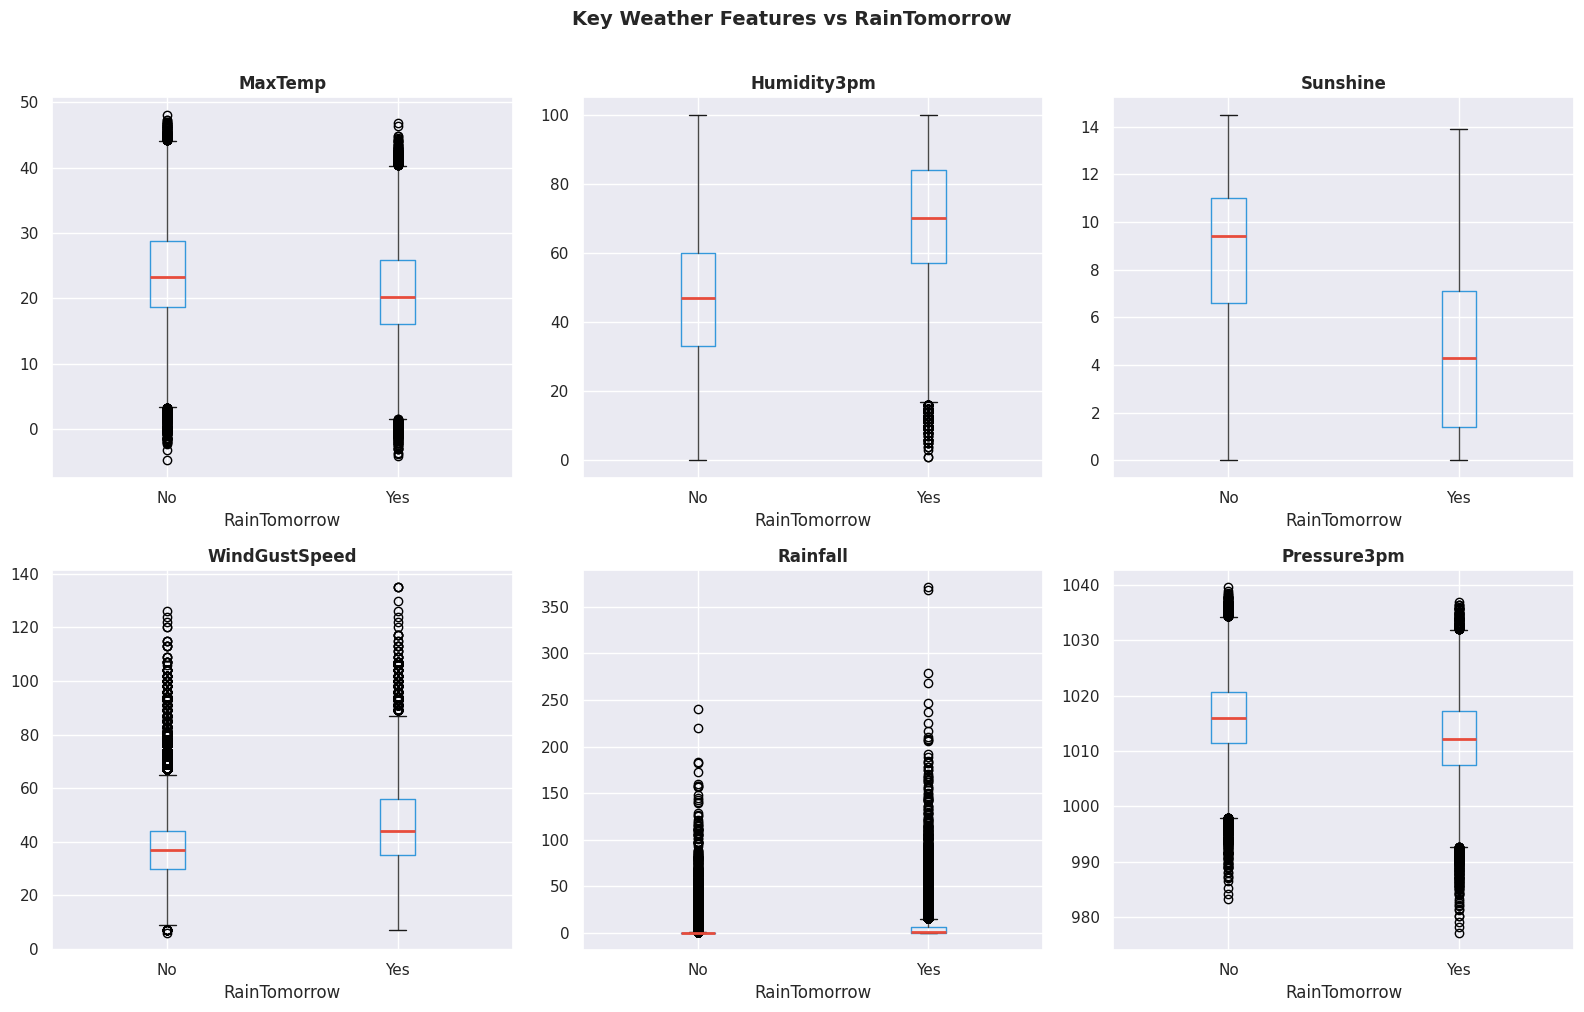

<Figure size 700x400 with 0 Axes>

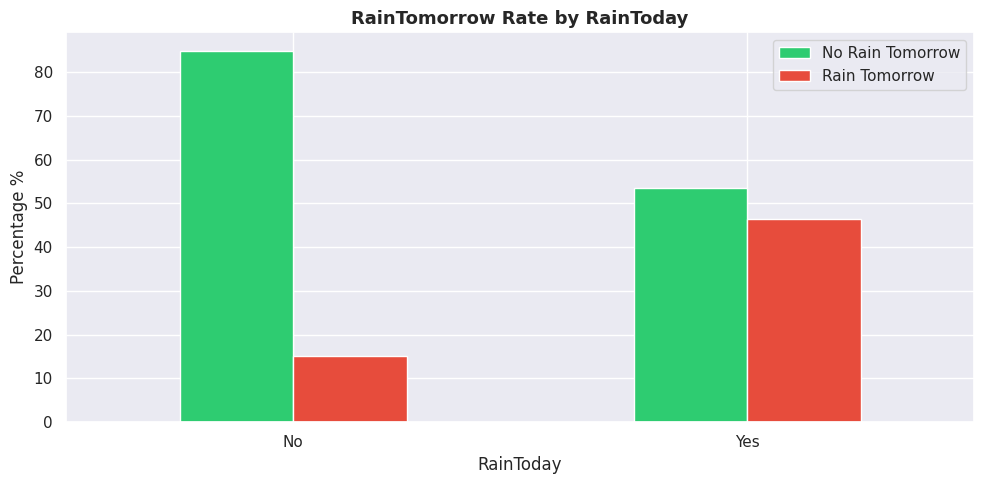

 EDA complete!


In [6]:
# ============================================================
# CELL 2 — Exploratory Data Analysis
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Target Distribution ---
df['RainTomorrow'].value_counts().plot(kind='bar', ax=axes[0],
                                       color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[0].set_title('Target Distribution: RainTomorrow', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(['No Rain', 'Rain'], rotation=0)
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():,}', (p.get_x() + 0.25, p.get_height() + 500))

# --- Missing Values Heatmap ---
missing = df.isnull().mean().mul(100).sort_values(ascending=False)
missing[missing > 0].plot(kind='bar', ax=axes[1], color='#e67e22', edgecolor='white')
axes[1].set_title('Missing Values % per Column', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Missing %')
axes[1].axhline(y=40, color='red', linestyle='--', linewidth=1, label='40% threshold')
axes[1].legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- Key numeric features vs RainTomorrow ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
num_features = ['MaxTemp', 'Humidity3pm', 'Sunshine',
                'WindGustSpeed', 'Rainfall', 'Pressure3pm']

for ax, feat in zip(axes.flatten(), num_features):
    df.boxplot(column=feat, by='RainTomorrow', ax=ax,
               boxprops=dict(color='#3498db'),
               medianprops=dict(color='#e74c3c', linewidth=2))
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('RainTomorrow')

plt.suptitle('Key Weather Features vs RainTomorrow', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# --- RainToday vs RainTomorrow ---
plt.figure(figsize=(7, 4))
pd.crosstab(df['RainToday'], df['RainTomorrow'], normalize='index').mul(100).plot(
    kind='bar', color=['#2ecc71', '#e74c3c'], edgecolor='white')
plt.title('RainTomorrow Rate by RainToday', fontsize=13, fontweight='bold')
plt.xticks(rotation=0)
plt.ylabel('Percentage %')
plt.legend(['No Rain Tomorrow', 'Rain Tomorrow'])
plt.tight_layout()
plt.show()

print(" EDA complete!")

## 3. Preprocessing

### Challenges specific to this dataset:
| Challenge | Strategy |
|-----------|----------|
| High missing % (Sunshine 48%, Evaporation 43%) | Drop columns above 40% missing |
| Moderate missing in numeric cols | **Median imputation** (robust to outliers) |
| Missing in categorical cols | **Mode imputation** |
| Wind direction (16 categories) | **Frequency encoding** instead of one-hot (avoids 16 dummy cols) |
| Date column | Extract **Month** as a cyclic feature — rainfall is seasonal |

>  **New concept here:** Frequency Encoding — replace each category with how 
> often it appears in the dataset. Useful when a categorical col has many unique 
> values and one-hot would explode the feature space.

In [7]:
# ============================================================
# CELL 3 — Preprocessing
# ============================================================

df_clean = df.copy()

# --- Step 1: Drop Date & high-missing columns ---
high_missing = ['Sunshine', 'Evaporation', 'Cloud9am', 'Cloud3pm']
df_clean.drop(columns=['Date'] + high_missing, inplace=True)
print(f"After dropping high-missing cols: {df_clean.shape}")

# --- Step 2: Drop rows where target is missing ---
df_clean.dropna(subset=['RainTomorrow'], inplace=True)
print(f"After dropping missing target rows: {df_clean.shape}")

# --- Step 3: Encode Target & Binary cols first ---
df_clean['RainTomorrow'] = df_clean['RainTomorrow'].map({'Yes': 1, 'No': 0})
df_clean['RainToday']    = df_clean['RainToday'].map({'Yes': 1, 'No': 0})

# --- Step 4: Extract Month from Date as seasonal signal ---
# (re-parse from original before we dropped it)
df_clean['Month'] = pd.to_datetime(df['Date']).dt.month

# --- Step 5: Frequency Encoding for Wind Direction cols ---
# Instead of 16 dummies per wind col, encode by frequency
# High freq direction = common wind = less informative
# Captures ordinal-like signal without exploding feature space
wind_cols = ['WindGustDir', 'WindDir9am', 'WindDir3pm']
for col in wind_cols:
    freq_map = df_clean[col].value_counts(normalize=True).to_dict()
    df_clean[col] = df_clean[col].map(freq_map)
    
print("Wind direction cols frequency-encoded ✅")

# --- Step 6: One-hot encode Location (49 cities → too many for freq enc) ---
# We'll just label encode since RF doesn't care about ordinality
le = LabelEncoder()
df_clean['Location'] = le.fit_transform(df_clean['Location'].astype(str))

# --- Step 7: Impute remaining missing values ---
num_cols = df_clean.select_dtypes(include='number').columns.tolist()
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()

# Median for numeric (robust to the extreme rainfall outliers we saw)
for col in num_cols:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

# Mode for any remaining categorical
for col in cat_cols:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print(f"Missing values remaining: {df_clean.isnull().sum().sum()}")
print(f"Final shape: {df_clean.shape}")

# --- Step 8: Split & Scale ---
X = df_clean.drop('RainTomorrow', axis=1)
y = df_clean['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")
print(" Preprocessing complete!")

After dropping high-missing cols: (145460, 18)
After dropping missing target rows: (142193, 18)
Wind direction cols frequency-encoded ✅
Missing values remaining: 0
Final shape: (142193, 19)

Train: (113754, 18) | Test: (28439, 18)
 Preprocessing complete!


## 4. Random Forest — Baseline Model

### How Random Forest works:
- Builds **N independent decision trees**, each trained on a **random bootstrap sample** of data
- At each split, only a **random subset of features** (`max_features`) is considered
- Final prediction = **majority vote** across all trees

### Key difference from Logistic Regression:
| | Logistic Regression | Random Forest |
|---|---|---|
| Decision boundary | Linear | Non-linear |
| Handles interactions |  Needs manual features |  Automatic |
| Interpretability | High (coefficients) | Medium (feature importance) |
| Speed | Fast | Slower |
| Missing values | Needs imputation | More robust |

### Why `class_weight='balanced'`?
Our data is 77/23 imbalanced. Without this, RF will bias toward predicting 
"No Rain" since it's the majority — giving high accuracy but poor recall on rain days.

        RANDOM FOREST — BASELINE RESULTS
              precision    recall  f1-score   support

     No Rain       0.86      0.96      0.91     22064
        Rain       0.77      0.46      0.58      6375

    accuracy                           0.85     28439
   macro avg       0.82      0.71      0.74     28439
weighted avg       0.84      0.85      0.83     28439

ROC-AUC Score: 0.8796


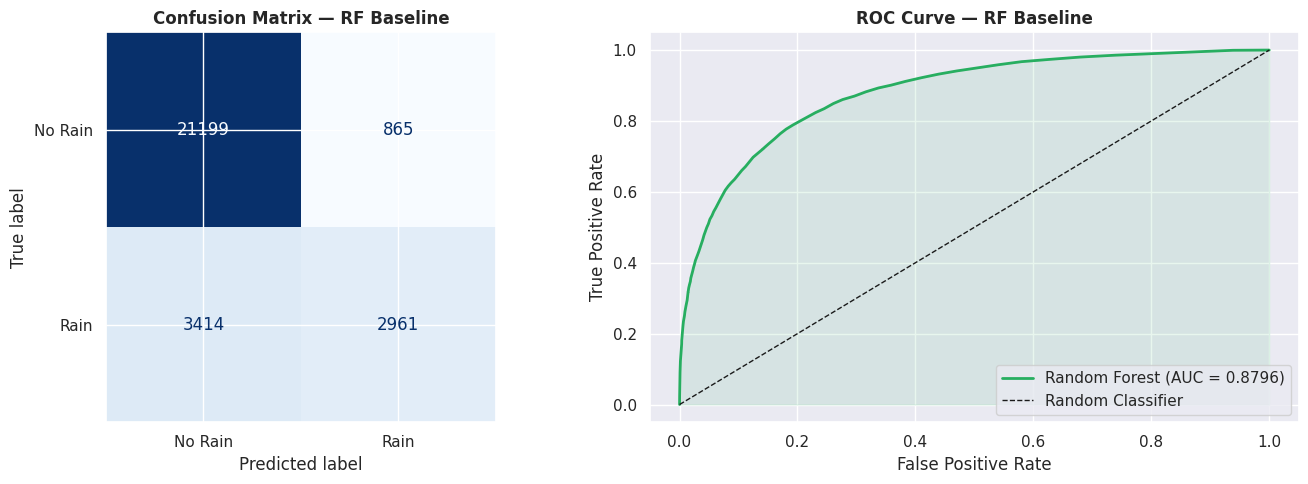

  Trees:  10 → CV AUC: 0.8351
  Trees:  25 → CV AUC: 0.8579
  Trees:  50 → CV AUC: 0.8678
  Trees: 100 → CV AUC: 0.8730
  Trees: 200 → CV AUC: 0.8757


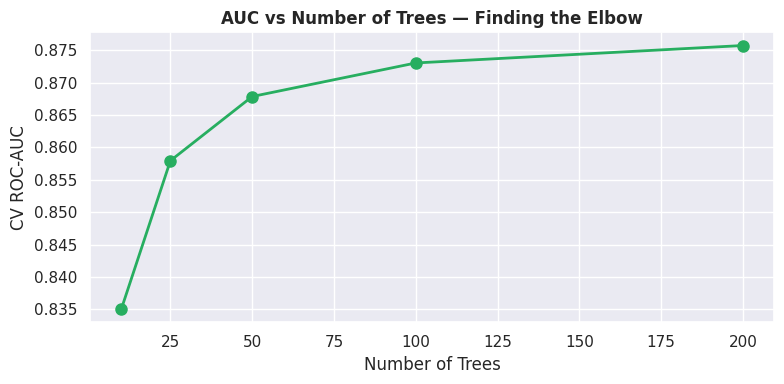

In [8]:
# ============================================================
# CELL 4 — Random Forest Baseline
# ============================================================

rf_baseline = RandomForestClassifier(
    n_estimators=100,        # 100 trees
    class_weight='balanced', # handle 77/23 imbalance
    random_state=42,
    n_jobs=-1                # use all CPU cores
)

rf_baseline.fit(X_train_scaled, y_train)
y_pred       = rf_baseline.predict(X_test_scaled)
y_pred_proba = rf_baseline.predict_proba(X_test_scaled)[:, 1]

print("=" * 55)
print("        RANDOM FOREST — BASELINE RESULTS")
print("=" * 55)
print(classification_report(y_test, y_pred,
                             target_names=['No Rain', 'Rain']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

# --- Confusion Matrix + ROC side by side ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Rain', 'Rain']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — RF Baseline', fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_score   = roc_auc_score(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='#27ae60', lw=2,
             label=f'Random Forest (AUC = {auc_score:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#27ae60')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — RF Baseline', fontweight='bold')
axes[1].legend(loc='lower right')
plt.tight_layout()
plt.show()

# --- Learning Curve: how does performance scale with more trees? ---
# New concept: see if 100 trees is enough or we need more
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

tree_counts = [10, 25, 50, 100, 200]
auc_scores  = []

for n in tree_counts:
    rf_temp = RandomForestClassifier(n_estimators=n, class_weight='balanced',
                                      random_state=42, n_jobs=-1)
    score = cross_val_score(rf_temp, X_train_scaled, y_train,
                            cv=3, scoring='roc_auc').mean()
    auc_scores.append(score)
    print(f"  Trees: {n:>3} → CV AUC: {score:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(tree_counts, auc_scores, marker='o', color='#27ae60', lw=2, markersize=8)
plt.xlabel('Number of Trees')
plt.ylabel('CV ROC-AUC')
plt.title('AUC vs Number of Trees — Finding the Elbow', fontweight='bold')
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Hyperparameter Tuning — Random Forest

### Key RF hyperparameters we'll tune:

| Parameter | What it controls | Effect |
|-----------|-----------------|--------|
| `max_depth` | How deep each tree grows | Deeper = more complex, risk of overfit |
| `min_samples_split` | Min samples needed to split a node | Higher = simpler trees, less overfit |
| `max_features` | Features considered at each split | Lower = more randomness, less correlation between trees |
| `n_estimators` | Fixed at 100 | From elbow plot above |

### Strategy: RandomizedSearchCV instead of GridSearchCV
RF has many hyperparameters — exhaustive grid search would take hours.  
**RandomizedSearchCV** samples N random combinations instead of trying all.  
Gives ~90% of the benefit in ~10% of the time. 🚀

Fitting 3 folds for each of 20 candidates, totalling 60 fits

 Best Parameters : {'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 0.3, 'max_depth': 20}
 Best CV ROC-AUC : 0.8743

        RANDOM FOREST — TUNED MODEL RESULTS
              precision    recall  f1-score   support

     No Rain       0.89      0.91      0.90     22064
        Rain       0.67      0.63      0.65      6375

    accuracy                           0.85     28439
   macro avg       0.78      0.77      0.77     28439
weighted avg       0.84      0.85      0.84     28439

ROC-AUC: 0.8808


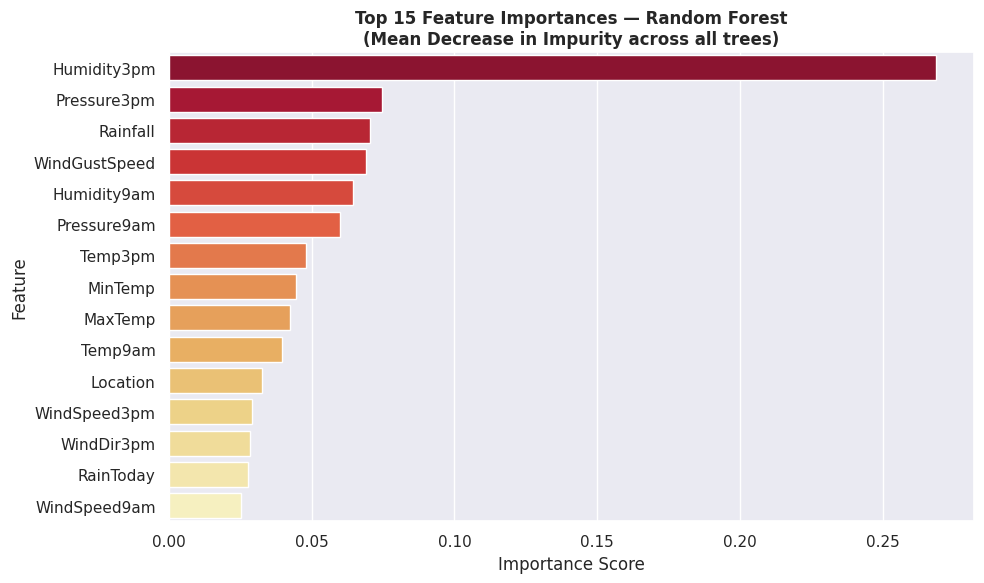

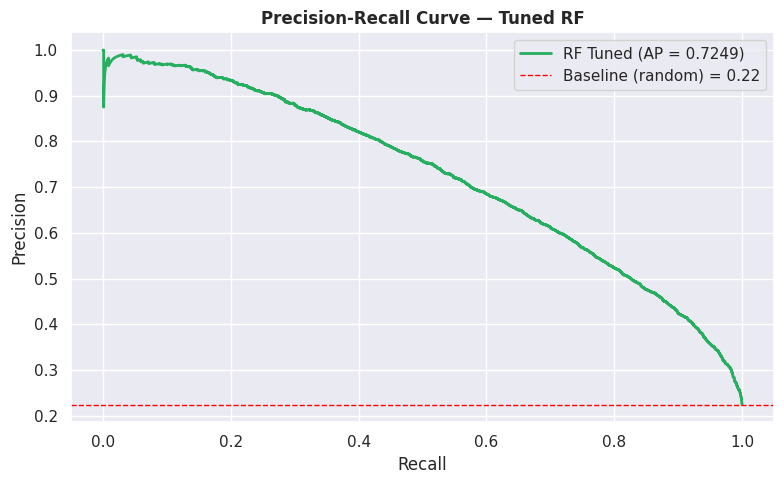

In [9]:
# ============================================================
# CELL 5 — RandomizedSearchCV Tuning + Feature Importance
# New concept: RandomizedSearchCV (faster than GridSearchCV)
# ============================================================

from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'max_depth'        : [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2', 0.3]
}

rf_tuned = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator   = rf_tuned,
    param_distributions = param_dist,
    n_iter      = 20,          # try 20 random combos (not all 180)
    cv          = cv,
    scoring     = 'roc_auc',
    n_jobs      = -1,
    random_state= 42,
    verbose     = 1
)

random_search.fit(X_train_scaled, y_train)

print(f"\n Best Parameters : {random_search.best_params_}")
print(f" Best CV ROC-AUC : {random_search.best_score_:.4f}")

# --- Evaluate ---
best_rf       = random_search.best_estimator_
y_pred_tuned  = best_rf.predict(X_test_scaled)
y_prob_tuned  = best_rf.predict_proba(X_test_scaled)[:, 1]

print("\n" + "=" * 55)
print("        RANDOM FOREST — TUNED MODEL RESULTS")
print("=" * 55)
print(classification_report(y_test, y_pred_tuned,
                             target_names=['No Rain', 'Rain']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_tuned):.4f}")

# --- Feature Importance (RF native — different from LR coefficients!) ---
# RF gives importance based on how much each feature reduces impurity across all trees
feat_imp = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x='Importance', y='Feature', 
            palette='YlOrRd_r', edgecolor='white')
plt.title('Top 15 Feature Importances — Random Forest\n'
          '(Mean Decrease in Impurity across all trees)',
          fontsize=12, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# --- Precision-Recall Curve (new concept — better than ROC for imbalanced!) ---
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob_tuned)
ap_score = average_precision_score(y_test, y_prob_tuned)

plt.figure(figsize=(8, 5))
plt.plot(recall_vals, precision_vals, color='#27ae60', lw=2,
         label=f'RF Tuned (AP = {ap_score:.4f})')
plt.axhline(y=y_test.mean(), color='red', linestyle='--', lw=1,
            label=f'Baseline (random) = {y_test.mean():.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Tuned RF', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Final Results & Key Learnings

### Model Comparison
| Model | Rain Recall | Rain Precision | ROC-AUC |
|-------|-------------|----------------|---------|
| RF Baseline | 0.46 | 0.77 | 0.8796 |
| RF Tuned | **0.63** | 0.67 | **0.8808** |

### Key Learnings from this Notebook

**On Data:**
- Real-world datasets have missing values — strategy matters (drop vs impute)
- Dropping columns >40% missing is safer than imputing with guesses
- Temporal features (Month) add signal — rainfall is seasonal

**On Encoding:**
- Frequency encoding for high-cardinality categoricals avoids dummy explosion
- Not every categorical needs one-hot — think about cardinality first

**On Modelling:**
- Random Forest handles non-linear patterns LR cannot
- `class_weight='balanced'` critical for imbalanced targets
- Elbow plot → 100 trees is the sweet spot (200 gives negligible gain)
- RandomizedSearchCV >> GridSearchCV when param space is large

**On Evaluation:**
- ROC-AUC can be optimistic on imbalanced data
- **Precision-Recall curve is more honest** — use it when minority class matters
- Average Precision (AP) summarizes the PR curve in one number

